<a href="https://colab.research.google.com/github/AHMEDVALL70/ahmed-vall-cv/blob/main/Saudi_RealEstate_Price_Predictor_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ السعر المتوقع: 2,277,500 ريال سعودي


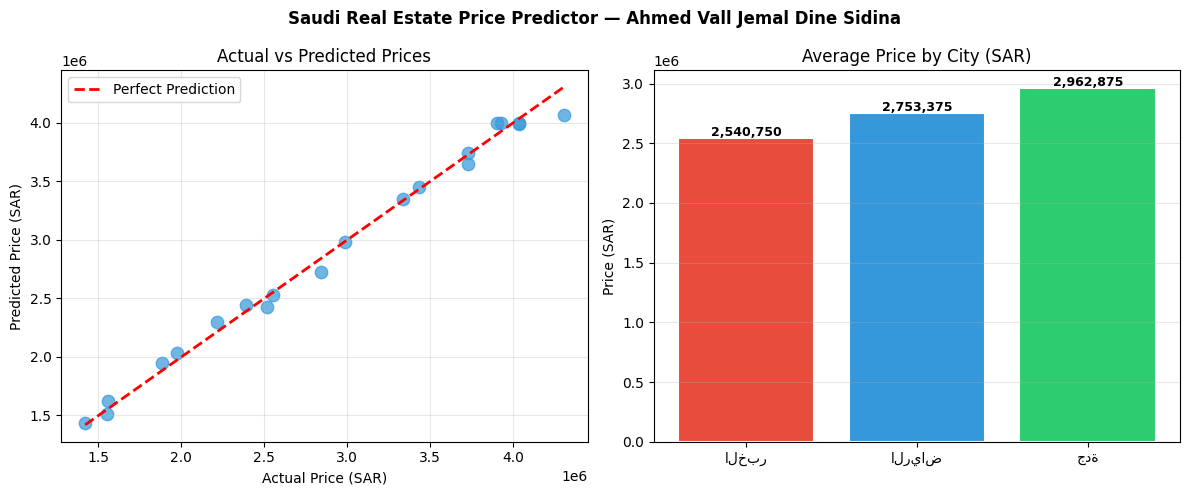

🎯 دقة النموذج R²: 99.27%


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# ── البيانات ──
data = {
    'city': ['الرياض', 'جدة', 'الرياض', 'الخبر', 'جدة'] * 20,
    'district': ['الياسمين', 'الشاطئ', 'النرجس', 'العزيزية', 'أبحر'] * 20,
    'area': np.random.randint(200, 800, 100),
    'rooms': np.random.randint(3, 8, 100),
    'price': 0
}
df_saudi = pd.DataFrame(data)
df_saudi['price'] = (df_saudi['area'] * 5000) + (df_saudi['rooms'] * 50000)

# ── تحويل النصوص لأرقام ──
le_city = LabelEncoder()
le_district = LabelEncoder()
df_saudi['city_n'] = le_city.fit_transform(df_saudi['city'])
df_saudi['district_n'] = le_district.fit_transform(df_saudi['district'])

# ── التدريب ──
X = df_saudi[['city_n', 'district_n', 'area', 'rooms']]
y = df_saudi['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_saudi = RandomForestRegressor(n_estimators=100, random_state=42)
model_saudi.fit(X_train, y_train)

# ── التوقع ──
sample_house = pd.DataFrame([[0, 2, 400, 5]],
    columns=['city_n', 'district_n', 'area', 'rooms'])
predicted_price = model_saudi.predict(sample_house)
print(f"✅ السعر المتوقع: {predicted_price[0]:,.0f} ريال سعودي")

# ── الرسم البياني ──
y_pred = model_saudi.predict(X_test)
r2 = r2_score(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Saudi Real Estate Price Predictor — Ahmed Vall Jemal Dine Sidina',
             fontsize=12, fontweight='bold')

# 1️⃣ Actual vs Predicted
axes[0].scatter(y_test, y_pred, color='#3498db', alpha=0.7, s=80)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_title('Actual vs Predicted Prices', fontsize=12)
axes[0].set_xlabel('Actual Price (SAR)')
axes[0].set_ylabel('Predicted Price (SAR)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2️⃣ متوسط السعر حسب المدينة
city_avg = df_saudi.groupby('city')['price'].mean()
colors = ['#e74c3c', '#3498db', '#2ecc71']
bars = axes[1].bar(city_avg.index, city_avg.values,
                    color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, city_avg.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 20000,
                 f'{val:,.0f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Average Price by City (SAR)', fontsize=12)
axes[1].set_ylabel('Price (SAR)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('saudi_realestate_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"🎯 دقة النموذج R²: {r2:.2%}")